In [ ]:
# Impor modul untuk akses Google Drive
from google.colab import drive

# Hubungkan Google Drive ke Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf

dataset_dir = "/content/drive/MyDrive/FNNPK"
image_size = (224, 224)

def decode_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img

def load_images_from_folder(dataset_path):
    image_list, label_list = [], []
    class_names = sorted(os.listdir(dataset_path))

    for label in class_names:
        class_folder = os.path.join(dataset_path, label)
        if not os.path.isdir(class_folder):
            continue

        for file_name in os.listdir(class_folder):
            file_path = os.path.join(class_folder, file_name)
            try:
                img = decode_image(file_path)
                img = tf.image.resize(img, image_size)
                img = tf.cast(img, tf.float32) / 255.0
                image_list.append(img)
                label_list.append(label)
            except Exception as e:
                print(f"Skipping file {file_path}: {e}")

    return image_list, label_list

# Load data
print(f"⏳ Memuat data dari {dataset_dir}...")
images, labels = load_images_from_folder(dataset_dir)
print(f"✅ Data berhasil dimuat ({len(images)} gambar).")
print("Contoh label:", labels[:10])

⏳ Memuat data dari /content/drive/MyDrive/FNNPK...
✅ Data berhasil dimuat (209 gambar).
Contoh label: ['-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K']


In [ ]:
import numpy as np
from collections import Counter

# Mapping label <-> angka
label2id = {label: i for i, label in enumerate(sorted(set(labels)))}
id2label = {i: label for label, i in label2id.items()}
int_labels = [label2id[l] for l in labels]

# Konversi ke numpy array
X = np.array([img.numpy() for img in images])
y = np.array(int_labels)

print("🔢 Label2ID:", label2id)
print("📊 Distribusi awal:", Counter(y))
print("🖼️ X shape:", X.shape, "y shape:", y.shape)

🔢 Label2ID: {'-K': 0, '-N': 1, '-P': 2, 'FN': 3}
📊 Distribusi awal: Counter({np.int64(0): 72, np.int64(2): 66, np.int64(1): 58, np.int64(3): 13})
🖼️ X shape: (209, 224, 224, 3) y shape: (209,)


In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Step 1: Split train 60% dan sisanya 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Step 2: Split sisa 40% menjadi val dan test masing-masing 50% dari 40% → 20% dari total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("📊 Distribusi train:", Counter(y_train))
print("📊 Distribusi val:", Counter(y_val))
print("📊 Distribusi test:", Counter(y_test))

📊 Distribusi train: Counter({np.int64(0): 43, np.int64(2): 39, np.int64(1): 35, np.int64(3): 8})
📊 Distribusi val: Counter({np.int64(2): 14, np.int64(0): 14, np.int64(1): 12, np.int64(3): 2})
📊 Distribusi test: Counter({np.int64(0): 15, np.int64(2): 13, np.int64(1): 11, np.int64(3): 3})


In [ ]:
from PIL import Image

base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
for split, X_split, y_split in [("train", X_train, y_train),
                                ("val", X_val, y_val),
                                ("test", X_test, y_test)]:
    split_dir = os.path.join(base_dir, split)
    os.makedirs(split_dir, exist_ok=True)

    for idx, (img_array, label_id) in enumerate(zip(X_split, y_split)):
        label_name = id2label[label_id]
        label_folder = os.path.join(split_dir, label_name)
        os.makedirs(label_folder, exist_ok=True)

        img_pil = Image.fromarray((img_array * 255).astype(np.uint8))
        img_pil.save(os.path.join(label_folder, f"{split}_{idx}.jpg"))

print("✅ Dataset sudah disimpan ke folder FNNPK_SPLIT (train/val/test).")

✅ Dataset sudah disimpan ke folder FNNPK_SPLIT (train/val/test).


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/train", image_size=(224,224), batch_size=32
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/val", image_size=(224,224), batch_size=32
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/test", image_size=(224,224), batch_size=32
)

print(train_ds)

Found 125 files belonging to 4 classes.
Found 42 files belonging to 4 classes.
Found 42 files belonging to 4 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Found 125 files belonging to 4 classes.


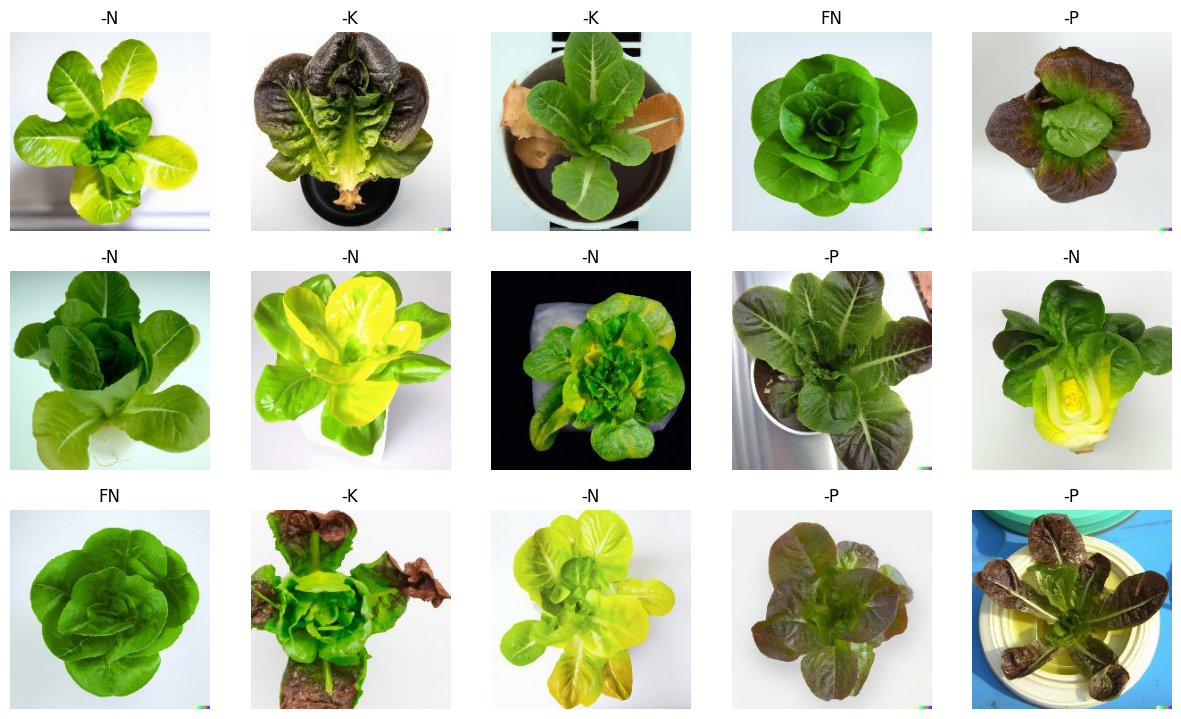

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Path dataset
train_path = "/content/drive/MyDrive/FNNPK_SPLIT/train"

# Load dataset train
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    batch_size=16
)

# Ambil satu batch
class_names = train_ds.class_names
images, labels = next(iter(train_ds))

plt.figure(figsize=(15, 15))
for i in range(15):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy().argmax()])
    plt.axis("off")
plt.show()

In [ ]:
import os

# Path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"

def count_images_per_class(split_dir):
    split_path = os.path.join(base_dir, split_dir)
    class_counts = {}
    for class_name in sorted(os.listdir(split_path)):
        class_folder = os.path.join(split_path, class_name)
        if os.path.isdir(class_folder):
            files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[class_name] = len(files)
    return class_counts

# Hitung distribusi
train_counts = count_images_per_class("train")
val_counts   = count_images_per_class("val")
test_counts  = count_images_per_class("test")

# Total semua
total_images = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())

print(f"📸 Total data keseluruhan: {total_images} gambar\n")

print("📊 Distribusi data setelah split:")

print("  🟢 Train:")
for cls, count in train_counts.items():
    print(f"    {cls}: {count} gambar")

print("  🟡 Validation:")
for cls, count in val_counts.items():
    print(f"    {cls}: {count} gambar")

print("  🔵 Test:")
for cls, count in test_counts.items():
    print(f"    {cls}: {count} gambar")

📸 Total data keseluruhan: 209 gambar

📊 Distribusi data setelah split:
  🟢 Train:
    -K: 43 gambar
    -N: 35 gambar
    -P: 39 gambar
    FN: 8 gambar
  🟡 Validation:
    -K: 14 gambar
    -N: 12 gambar
    -P: 14 gambar
    FN: 2 gambar
  🔵 Test:
    -K: 15 gambar
    -N: 11 gambar
    -P: 13 gambar
    FN: 3 gambar


In [ ]:
import os
from collections import Counter
import numpy as np

# base path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# ambil daftar kelas (dari folder di train)
class_names = sorted(os.listdir(train_dir))
label2id = {c: i for i, c in enumerate(class_names)}
id2label = {i: c for c, i in label2id.items()}

print("🏷️ Mapping label:", label2id)

🏷️ Mapping label: {'-K': 0, '-N': 1, '-P': 2, 'FN': 3}


In [ ]:
def load_paths_and_labels(split_dir):
    paths, labels = [], []
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                paths.append(os.path.join(cls_path, f))
                labels.append(label2id[cls])
    return paths, labels

train_paths, train_labels = load_paths_and_labels(train_dir)
val_paths, val_labels     = load_paths_and_labels(val_dir)
test_paths, test_labels   = load_paths_and_labels(test_dir)

print("📊 Jumlah data per split:")
print("  Train:", len(train_paths))
print("  Val:", len(val_paths))
print("  Test:", len(test_paths))

print("🎯 Distribusi Train:", Counter(train_labels))
print("🎯 Distribusi Val:", Counter(val_labels))
print("🎯 Distribusi Test:", Counter(test_labels))

📊 Jumlah data per split:
  Train: 125
  Val: 42
  Test: 42
🎯 Distribusi Train: Counter({0: 43, 2: 39, 1: 35, 3: 8})
🎯 Distribusi Val: Counter({0: 14, 2: 14, 1: 12, 3: 2})
🎯 Distribusi Test: Counter({0: 15, 2: 13, 1: 11, 3: 3})


In [ ]:
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, save_img

# path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

IMG_SIZE = (224, 224)

In [ ]:
def oversample_class(train_dir, target_class, target_count):
    class_dir = os.path.join(train_dir, target_class)
    files = os.listdir(class_dir)
    current_count = len(files)

    if current_count >= target_count:
        print(f"✔ {target_class} sudah cukup ({current_count} gambar).")
        return

    i = 0
    while len(os.listdir(class_dir)) < target_count:
        src = os.path.join(class_dir, files[i % current_count])
        dst = os.path.join(class_dir, f"copy_{i}_{files[i % current_count]}")
        shutil.copy(src, dst)
        i += 1

    print(f"✅ Oversampling {target_class}: dari {current_count} → {len(os.listdir(class_dir))} gambar")

target_size = 50
for class_name in os.listdir(train_dir):
    oversample_class(train_dir, class_name, target_size)

✅ Oversampling -N: dari 35 → 50 gambar
✅ Oversampling -K: dari 43 → 50 gambar
✅ Oversampling -P: dari 39 → 50 gambar
✅ Oversampling FN: dari 8 → 50 gambar


In [ ]:
aug_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

def augment_images(class_dir, augment_count=3):
    files = os.listdir(class_dir)
    for file in files:
        img_path = os.path.join(class_dir, file)
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        # generate augment_count versi baru
        aug_iter = aug_datagen.flow(x, batch_size=1, save_to_dir=class_dir, save_prefix="aug", save_format="jpg")
        for i in range(augment_count):
            next(aug_iter)

# contoh augment semua kelas
for class_name in os.listdir(train_dir):
    print(f"🔄 Augmentasi kelas {class_name}...")
    augment_images(os.path.join(train_dir, class_name), augment_count=3)

🔄 Augmentasi kelas -N...
🔄 Augmentasi kelas -K...
🔄 Augmentasi kelas -P...
🔄 Augmentasi kelas FN...


In [ ]:
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical"
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 797 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
Found 42 images belonging to 4 classes.


In [ ]:
import os

# path dataset final
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"

def count_images(split_dir):
    split_path = os.path.join(base_dir, split_dir)
    class_counts = {}
    for cls in sorted(os.listdir(split_path)):
        class_folder = os.path.join(split_path, cls)
        if os.path.isdir(class_folder):
            files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[cls] = len(files)
    return class_counts

train_counts = count_images("train")
val_counts   = count_images("val")
test_counts  = count_images("test")

print("📊 Distribusi data:")
print("  🟢 Train:", train_counts)
print("  🟡 Validation:", val_counts)
print("  🔵 Test:", test_counts)

print(f"\n📸 Total gambar: {sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())}")

📊 Distribusi data:
  🟢 Train: {'-K': 199, '-N': 200, '-P': 198, 'FN': 200}
  🟡 Validation: {'-K': 14, '-N': 12, '-P': 14, 'FN': 2}
  🔵 Test: {'-K': 15, '-N': 11, '-P': 13, 'FN': 3}

📸 Total gambar: 881


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ====== Setup folder dataset ======
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# ====== Data Generator ======
train_datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ====== Model EfficientNetB1 ======
input_layer = Input(shape=(224, 224, 3))
effnet = EfficientNetB1(include_top=False, weights="imagenet", input_tensor=input_layer)
effnet.trainable = False  # freeze semua layer awal

x = GlobalAveragePooling2D()(effnet.output)
x = Dropout(0.7)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

efficient_model = Model(inputs=input_layer, outputs=output)

# ====== Compile Stage 1 (Feature Extractor) ======
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage1 = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ModelCheckpoint("efficient_stage1.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

print("=== Training Stage 1 (Feature Extraction) ===")
history_stage1 = efficient_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_stage1,
    verbose=1
)

# ====== Stage 2a: Fine-Tuning Ringan ======
print("=== Training Stage 2a (Fine-Tuning Ringan) ===")
for layer in effnet.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage2a = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ModelCheckpoint("efficient_stage2a.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
]

history_stage2a = efficient_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_stage2a,
    verbose=1
)

Found 794 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Training Stage 1 (Feature Extraction) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.2130 - loss: 1.8190 - top_2_acc: 0.4868 - val_accuracy: 0.1905 - val_loss: 1.6959 - val_top_2_acc: 0.3571 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.2743 - loss: 1.6904 - top_2_acc: 0.5063 - val_accuracy: 0.2143 - val_loss: 1.5513 - val_top_2_acc: 0.4762 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - accuracy: 0.3396 - loss: 1.5245 - top_2_acc: 0.5814 - val_accuracy: 0.2619 - val_loss: 1.4612 - val_top_2_acc: 0.5952 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - accuracy: 0.4249 - loss: 1.3261 - top_2_acc: 0.6731 - val_accuracy: 0.3333 - val_loss: 1.3879 - val_top_2_acc: 0.6667 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.4131 - loss: 1.3186 - top_2_acc: 0.7046 - val_accuracy: 0.3571 - val_loss: 1.3290 - val_top_2_acc: 0.6905 - learning_rate: 1.0000e-0

In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

# --- Evaluasi Model Terbaik ---

print("\n=== Memuat Model Terbaik untuk Evaluasi ===")
# Muat model terbaik yang disimpan dari tahap fine-tuning
# Pastikan nama file "efficient_stage2a.keras" sudah benar
best_model = tf.keras.models.load_model("efficient_stage2a.keras")

# Pastikan generator tes di-reset sebelum prediksi agar urutannya benar
test_gen.reset()

print("\n=== Melakukan Prediksi pada Data Tes ===")
# Lakukan prediksi pada seluruh data tes
test_preds = best_model.predict(test_gen, verbose=1)

# Ambil kelas dengan probabilitas tertinggi sebagai kelas prediksi
test_pred_classes = np.argmax(test_preds, axis=1)

# Ambil kelas yang sebenarnya (ground truth) dari generator
test_true_classes = test_gen.classes

# --- Perhitungan Cohen's Kappa ---

print("\n=== Menghitung Cohen's Kappa Score ===")
# Hitung skor Kappa dengan membandingkan label asli dan label prediksi
kappa_score = cohen_kappa_score(test_true_classes, test_pred_classes)

print(f"\nSkor Cohen's Kappa pada Data Tes: {kappa_score:.4f}")

# Opsional: Menambahkan interpretasi singkat
if kappa_score < 0.20:
    interpretation = "Buruk (Slight)"
elif kappa_score < 0.40:
    interpretation = "Cukup (Fair)"
elif kappa_score < 0.60:
    interpretation = "Sedang (Moderate)"
elif kappa_score < 0.80:
    interpretation = "Baik (Substantial)"
else:
    interpretation = "Sangat Baik (Almost Perfect)"

print(f"Tingkat Kesepakatan: {interpretation}")


=== Memuat Model Terbaik untuk Evaluasi ===

=== Melakukan Prediksi pada Data Tes ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step

=== Menghitung Cohen's Kappa Score ===

Skor Cohen's Kappa pada Data Tes: 0.8331
Tingkat Kesepakatan: Sangat Baik (Almost Perfect)


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ====== Setup folder dataset ======
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# ====== Data Generator ======
train_datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ====== Model DenseNet121 ======
input_layer = Input(shape=(224, 224, 3))
densenet = DenseNet121(include_top=False, weights="imagenet", input_tensor=input_layer)
densenet.trainable = False

x = GlobalAveragePooling2D()(densenet.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_gen.num_classes, activation="softmax")(x)

dense_model = Model(inputs=input_layer, outputs=output)

# ====== Compile Stage 1 (Feature Extractor) ======
dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", "categorical_crossentropy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage1 = [
    EarlyStopping(monitor="val_categorical_crossentropy", patience=5, restore_best_weights=True),
    ModelCheckpoint("densenet_densehead_stage1.keras", save_best_only=True, monitor="val_categorical_crossentropy"),
    ReduceLROnPlateau(monitor="val_categorical_crossentropy", factor=0.5, patience=3, min_lr=2e-7)
]

print("=== Training Stage 1 (Feature Extraction) ===")
history_stage1 = dense_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_stage1,
    verbose=1
)

# ====== Stage 2: Fine-Tuning ======
print("=== Training Stage 2 (Fine-Tuning) ===")

# Membuka 50 layer terakhir untuk fine-tuning
for layer in densenet.layers[-50:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", "categorical_crossentropy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage2 = [
    EarlyStopping(monitor="val_categorical_crossentropy", patience=5, restore_best_weights=True),
    ModelCheckpoint("densenet_densehead_stage2.keras", save_best_only=True, monitor="val_categorical_crossentropy"),
    ReduceLROnPlateau(monitor="val_categorical_crossentropy", factor=0.5, patience=3, min_lr=1e-7)
]

print("=== Starting Fine-Tuning ===")
history_stage2 = dense_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_stage2,
    verbose=1
)

print("=== Pelatihan Selesai ===")

Found 797 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
=== Training Stage 1 (Feature Extraction) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 869ms/step - accuracy: 0.3089 - categorical_crossentropy: 11.8122 - loss: 11.8122 - top_2_acc: 0.5278 - val_accuracy: 0.5238 - val_categorical_crossentropy: 2.8095 - val_loss: 2.8095 - val_top_2_acc: 0.6190 - learning_rate: 1.0000e-05
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.3642 - categorical_crossentropy: 8.7706 - loss: 8.7706 - top_2_acc: 0.5968 - val_accuracy: 0.4524 - val_categorical_crossentropy: 2.2418 - val_loss: 2.2418 - val_top_2_acc: 0.6905 - learning_rate: 1.0000e-05
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.3377 - categorical_crossentropy: 8.1771 - loss: 8.1771 - top_2_acc: 0.6327 - val_accuracy: 0.5238 - val_categorical_crossentropy: 2.0209 - val_loss: 2.0209 - val_top_2_acc: 0.7143 - learning_rate: 1.0000e-05
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.3727 - categorical_crossentropy: 7.8204 - loss: 7.8204 - top_2_acc: 0.6105 - val_accuracy: 0.5714 - val_ca

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ====== Gabungkan history stage1 + stage2a ======
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2)

# ====== Buat DataFrame ======
df_history = pd.DataFrame(full_history)
df_history.index += 1  # mulai dari epoch 1

# tampilkan per 5 epoch
print("=== Ringkasan per 5 epoch ===")
print(df_history.iloc[::5, :][["accuracy", "val_accuracy", "loss", "val_loss"]])

# ====== Cari best model (val_loss terendah) ======
best_epoch = df_history["val_loss"].idxmin()
best_val_loss = df_history.loc[best_epoch, "val_loss"]
best_val_acc = df_history.loc[best_epoch, "val_accuracy"]

print(f"\n=== Best Model (berdasarkan val_loss) ===")
print(f"Epoch: {best_epoch}")
print(f"Val Loss: {best_val_loss:.4f}")
print(f"Val Accuracy: {best_val_acc:.4f}")

=== Ringkasan per 5 epoch ===
    accuracy  val_accuracy       loss  val_loss
1   0.321205      0.523810  10.772019  2.809519
6   0.398996      0.595238   6.566761  1.506605
11  0.508156      0.666667   4.617203  1.208836
16  0.575910      0.714286   3.648678  0.972545
21  0.554580      0.714286   3.547116  0.971665
26  0.597240      0.738095   3.000758  0.937423
31  0.649937      0.761905   2.615136  0.940697
36  0.734003      0.785714   1.508480  0.784640
41  0.801757      0.857143   0.853225  0.509639
46  0.836888      0.857143   0.680559  0.462808
51  0.878294      0.904762   0.359179  0.448925
56  0.887077      0.857143   0.333360  0.369762
61  0.907152      0.904762   0.310199  0.333919

=== Best Model (berdasarkan val_loss) ===
Epoch: 60
Val Loss: 0.3159
Val Accuracy: 0.8810


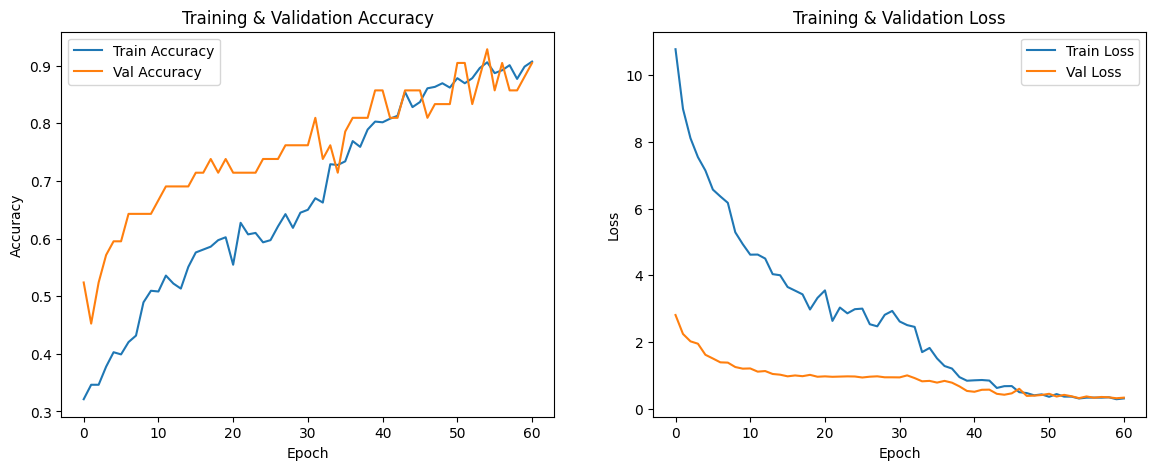

In [ ]:
import matplotlib.pyplot as plt

# ==== Gabungkan history stage1 + stage2a ====
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2)

# ==== Plot Accuracy & Loss ====
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(full_history["accuracy"], label="Train Accuracy")
plt.plot(full_history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(full_history["loss"], label="Train Loss")
plt.plot(full_history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


=== Evaluasi Model pada Test Data ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.8780 - categorical_crossentropy: 0.6405 - loss: 0.6405 - top_2_acc: 0.9881
Test Loss (Total)          : 0.9328
Test Categorical Crossentropy: 0.9328
Test Accuracy              : 0.8810
Test Top-2 Accuracy        : 0.9762
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step

=== Classification Report (Test Data) ===
              precision    recall  f1-score   support

          -K       0.93      0.87      0.90        15
          -N       0.90      0.82      0.86        11
          -P       0.81      1.00      0.90        13
          FN       1.00      0.67      0.80         3

    accuracy                           0.88        42
   macro avg       0.91      0.84      0.86        42
weighted avg       0.89      0.88      0.88        42


=== Menampilkan Confusion Matrix ===


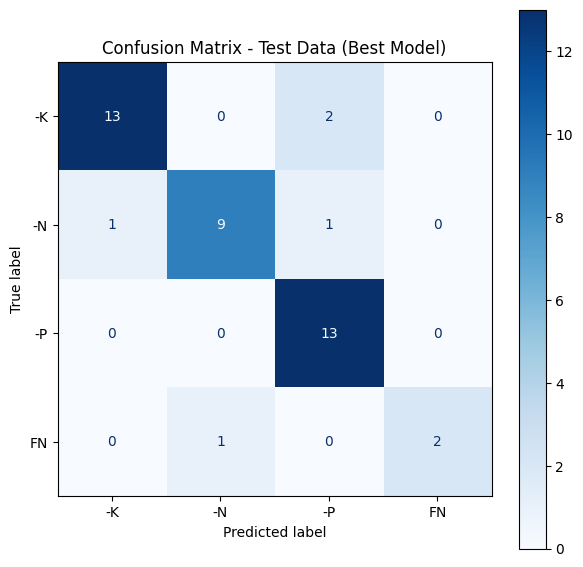

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# ==== Load best model dari checkpoint ====
try:
    best_model = tf.keras.models.load_model("densenet_densehead_stage2.keras")
except Exception as e:
    print(f"Error saat load model: {e}")
    print("Pastikan file 'densenet_densehead_stage2.keras' ada di direktori yang sama.")
    exit()

# ==== Evaluasi di dataset test ====
print("\n=== Evaluasi Model pada Test Data ===")
# DIUBAH: Sediakan 4 variabel untuk menampung 4 hasil dari .evaluate()
test_loss, test_acc, test_cat_crossentropy, test_top2 = best_model.evaluate(test_gen, verbose=1)

print(f"Test Loss (Total)          : {test_loss:.4f}")
# DITAMBAHKAN: Tampilkan juga categorical crossentropy murni
print(f"Test Categorical Crossentropy: {test_cat_crossentropy:.4f}")
print(f"Test Accuracy              : {test_acc:.4f}")
print(f"Test Top-2 Accuracy        : {test_top2:.4f}")
# =================================================================

# ==== Prediksi kelas di test set ====
test_gen.reset()
test_preds = best_model.predict(test_gen, verbose=1)
test_pred_classes = np.argmax(test_preds, axis=1)
test_true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# ==== Classification Report ====
print("\n=== Classification Report (Test Data) ===")
print(classification_report(test_true_classes, test_pred_classes, target_names=class_labels))

# ==== Confusion Matrix ====
print("\n=== Menampilkan Confusion Matrix ===")
cm = confusion_matrix(test_true_classes, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Data (Best Model)")
fig = plt.gcf()
fig.set_size_inches(7, 7)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

# --- Evaluasi Model Terbaik ---

print("\n=== Memuat Model Terbaik untuk Evaluasi ===")
# Muat model terbaik yang disimpan dari tahap fine-tuning
# Pastikan nama file "efficient_stage2a.keras" sudah benar
best_model = tf.keras.models.load_model("densenet_densehead_stage2.keras")

# Pastikan generator tes di-reset sebelum prediksi agar urutannya benar
test_gen.reset()

print("\n=== Melakukan Prediksi pada Data Tes ===")
# Lakukan prediksi pada seluruh data tes
test_preds = best_model.predict(test_gen, verbose=1)

# Ambil kelas dengan probabilitas tertinggi sebagai kelas prediksi
test_pred_classes = np.argmax(test_preds, axis=1)

# Ambil kelas yang sebenarnya (ground truth) dari generator
test_true_classes = test_gen.classes

# --- Perhitungan Cohen's Kappa ---

print("\n=== Menghitung Cohen's Kappa Score ===")
# Hitung skor Kappa dengan membandingkan label asli dan label prediksi
kappa_score = cohen_kappa_score(test_true_classes, test_pred_classes)

print(f"\nSkor Cohen's Kappa pada Data Tes: {kappa_score:.4f}")

# Opsional: Menambahkan interpretasi singkat
if kappa_score < 0.20:
    interpretation = "Buruk (Slight)"
elif kappa_score < 0.40:
    interpretation = "Cukup (Fair)"
elif kappa_score < 0.60:
    interpretation = "Sedang (Moderate)"
elif kappa_score < 0.80:
    interpretation = "Baik (Substantial)"
else:
    interpretation = "Sangat Baik (Almost Perfect)"

print(f"Tingkat Kesepakatan: {interpretation}")


=== Memuat Model Terbaik untuk Evaluasi ===

=== Melakukan Prediksi pada Data Tes ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 26s 7s/step

=== Menghitung Cohen's Kappa Score ===

Skor Cohen's Kappa pada Data Tes: 0.8293
Tingkat Kesepakatan: Sangat Baik (Almost Perfect)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB1, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ====== Input ======
IMG_SIZE = (224,224,3)
num_classes = train_gen.num_classes

input_layer = tf.keras.Input(shape=IMG_SIZE)

# ====== EfficientNetB1 Backbone ======
effnet = EfficientNetB1(include_top=False, weights="imagenet", input_tensor=input_layer)
effnet.trainable = False
x_eff = layers.GlobalAveragePooling2D()(effnet.output)

# ====== DenseNet121 Backbone ======
densenet = DenseNet121(include_top=False, weights="imagenet", input_tensor=input_layer)
densenet.trainable = False
x_dense = layers.GlobalAveragePooling2D()(densenet.output)

# ====== Gabungkan feature ======
x = layers.concatenate([x_eff, x_dense])
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

# ====== Hybrid Model ======
hybrid_model = Model(inputs=input_layer, outputs=output)

# ====== Compile tahap 1 (freeze backbone) ======
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage1 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("hybrid_stage1.keras", save_best_only=True, monitor="val_loss", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ====== Training tahap 1 ======
history_stage1 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_stage1,
    verbose=1
)

# ====== Fine-tuning backbone ======
trainable_layers_eff = 20
trainable_layers_dense = 20

for layer in effnet.layers[-trainable_layers_eff:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

for layer in densenet.layers[-trainable_layers_dense:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Compile ulang dengan learning rate lebih kecil
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage2 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("hybrid_stage2.keras", save_best_only=True, monitor="val_loss", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

# ====== Training tahap 2 ======
history_stage2 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_stage2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2318 - loss: 1.6442 - top_2_acc: 0.4874
Epoch 1: val_loss improved from inf to 1.33990, saving model to hybrid_stage1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.2339 - loss: 1.6424 - top_2_acc: 0.4886 - val_accuracy: 0.3810 - val_loss: 1.3399 - val_top_2_acc: 0.6429 - learning_rate: 1.0000e-04
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3053 - loss: 1.5018 - top_2_acc: 0.5904
Epoch 2: val_loss improved from 1.33990 to 1.28956, saving model to hybrid_stage1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.3056 - loss: 1.5008 - top_2_acc: 0.5906 - val_accuracy: 0.4048 - val_loss: 1.2896 - val_top_2_acc: 0.6667 - learning_rate: 1.0000e-04
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3664 - loss: 1.4507 - top_2_acc: 0.5899
Epoch 3: val_loss improved from 1.28956 to 1.22665, saving model to hybrid_stage1.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accurac

In [ ]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

# --- Evaluasi Model Terbaik ---

print("\n=== Memuat Model Terbaik untuk Evaluasi ===")
# Muat model terbaik yang disimpan dari tahap fine-tuning
# Pastikan nama file "efficient_stage2a.keras" sudah benar
best_model = tf.keras.models.load_model("hybrid_stage2.keras")

# Pastikan generator tes di-reset sebelum prediksi agar urutannya benar
test_gen.reset()

print("\n=== Melakukan Prediksi pada Data Tes ===")
# Lakukan prediksi pada seluruh data tes
test_preds = best_model.predict(test_gen, verbose=1)

# Ambil kelas dengan probabilitas tertinggi sebagai kelas prediksi
test_pred_classes = np.argmax(test_preds, axis=1)

# Ambil kelas yang sebenarnya (ground truth) dari generator
test_true_classes = test_gen.classes

# --- Perhitungan Cohen's Kappa ---

print("\n=== Menghitung Cohen's Kappa Score ===")
# Hitung skor Kappa dengan membandingkan label asli dan label prediksi
kappa_score = cohen_kappa_score(test_true_classes, test_pred_classes)

print(f"\nSkor Cohen's Kappa pada Data Tes: {kappa_score:.4f}")

# Opsional: Menambahkan interpretasi singkat
if kappa_score < 0.20:
    interpretation = "Buruk (Slight)"
elif kappa_score < 0.40:
    interpretation = "Cukup (Fair)"
elif kappa_score < 0.60:
    interpretation = "Sedang (Moderate)"
elif kappa_score < 0.80:
    interpretation = "Baik (Substantial)"
else:
    interpretation = "Sangat Baik (Almost Perfect)"

print(f"Tingkat Kesepakatan: {interpretation}")


=== Memuat Model Terbaik untuk Evaluasi ===

=== Melakukan Prediksi pada Data Tes ===
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 23s/step

=== Menghitung Cohen's Kappa Score ===

Skor Cohen's Kappa pada Data Tes: 0.9323
Tingkat Kesepakatan: Sangat Baik (Almost Perfect)


In [ ]:
# ==== Simpan model dalam format .keras ====
best_model.save("/content/drive/MyDrive/saved_model_hybrid.keras")

# ==== Konversi ke TFLite ====
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

# Simpan ke Google Drive
with open("/content/drive/MyDrive/model_hybrid.tflite", "wb") as f:
    f.write(tflite_model)

print("Model sudah tersimpan di Google Drive!")

Saved artifact at '/tmp/tmplg0vke73'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139947826343248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139942185963344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139942185962000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951510419600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139942185961616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962875600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962875408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962867728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962867920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962874256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139946962874832